## **Figure-S11**

Here show Figure 3A on the protein level. Trends are differing for DIA-NN which is interesting. 

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from collections import defaultdict
import os
import numpy as np
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import sys

In [2]:
sys.path.append("../../scripts")

from figure_utils import *

In [3]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [4]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014')

condition = dict(orig='Initial', refined='Reconstructed', tl='Transfer-Learn')

In [5]:
def getProteinSet_oswpq_alt(fPath, cutoff=0.01):
    # for the in-silico frags, the protein decoy labels are broken. To get accurate numbers, do not look for "Protein_DECOY" and then just filter proteins that have decoy in the name afterwards
    print(fPath)
    parquet = pl.scan_parquet(os.path.join(fPath, "precursors_features.parquet"))
    out =  set(parquet.filter((pl.col('SCORE_MS2_PEAK_GROUP_RANK') == 1) & 
                              (pl.col('SCORE_PROTEIN_GLOBAL_Q_VALUE') <= 0.01))
                          .select('PROTEIN_ACCESSION')
           .unique()
           .collect()
           .to_series())
    return { i for i in out if 'DECOY' not in i }

---

---

## **Load Data**

#### **Load IDs Vs Reproducibility Data**

In [6]:
diann_prot = { n:defaultdict(dict) for n in names.values() }
osw_prot = { n:defaultdict(dict) for n in names.values() }

In [7]:
# Bruker data
diann_prot[names['bruker']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['bruker']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['bruker']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann_prot[names['bruker']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['bruker']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['bruker']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann_prot[names['bruker']][condition['tl']]['1'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['bruker']][condition['tl']]['2'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['bruker']][condition['tl']]['3'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# Silico data
diann_prot[names['silico']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['silico']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['silico']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann_prot[names['silico']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['silico']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['silico']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann_prot[names['silico']][condition['tl']]['1'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['silico']][condition['tl']]['2'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['silico']][condition['tl']]['3'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# exp data
diann_prot[names['exp']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['exp']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['exp']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann_prot[names['exp']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann_prot[names['exp']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann_prot[names['exp']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)

diann_prot[names['exp']][condition['tl']]['1'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann_prot[names['exp']][condition['tl']]['2'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann_prot[names['exp']][condition['tl']]['3'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)

# Panhuman data
diann_prot[names['panhuman']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['panhuman']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['panhuman']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann_prot[names['panhuman']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['panhuman']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['panhuman']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann_prot[names['panhuman']][condition['tl']]['1'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_prot[names['panhuman']][condition['tl']]['2'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann_prot[names['panhuman']][condition['tl']]['3'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")


../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2u

In [8]:
# Bruker data
osw_prot[names['bruker']][condition['orig']]['1'] = getProteinSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_prot[names['bruker']][condition['orig']]['2'] = getProteinSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw_prot[names['bruker']][condition['orig']]['3'] = getProteinSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw_prot[names['bruker']][condition['refined']]['1'] = getProteinSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_prot[names['bruker']][condition['refined']]['2'] = getProteinSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw_prot[names['bruker']][condition['refined']]['3'] = getProteinSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw_prot[names['bruker']][condition['tl']]['1'] = getProteinSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw_prot[names['bruker']][condition['tl']]['2'] = getProteinSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw_prot[names['bruker']][condition['tl']]['3'] = getProteinSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

# Panhuman data
osw_prot[names['panhuman']][condition['orig']]['1'] = getProteinSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw_prot[names['panhuman']][condition['orig']]['2'] = getProteinSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw_prot[names['panhuman']][condition['orig']]['3'] = getProteinSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw_prot[names['panhuman']][condition['refined']]['1'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw_prot[names['panhuman']][condition['refined']]['2'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw_prot[names['panhuman']][condition['refined']]['3'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw_prot[names['panhuman']][condition['tl'] ]['1'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw_prot[names['panhuman']][condition['tl'] ]['2'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw_prot[names['panhuman']][condition['tl'] ]['3'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

# Experimental data
osw_prot[names['exp']][condition['orig']]['1'] = getProteinSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_prot[names['exp']][condition['orig']]['2'] = getProteinSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw_prot[names['exp']][condition['orig']]['3'] = getProteinSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw_prot[names['exp']][condition['refined']]['1'] = getProteinSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_prot[names['exp']][condition['refined']]['2'] = getProteinSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw_prot[names['exp']][condition['refined']]['3'] = getProteinSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw_prot[names['exp']][condition['tl']]['1'] = getProteinSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw_prot[names['exp']][condition['tl']]['2'] = getProteinSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw_prot[names['exp']][condition['tl']]['3'] = getProteinSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

# Silico data
osw_prot[names['silico']][condition['orig']]['1'] = getProteinSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw_prot[names['silico']][condition['orig']]['2'] = getProteinSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw_prot[names['silico']][condition['orig']]['3'] = getProteinSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw_prot[names['silico']][condition['refined']]['1'] = getProteinSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_prot[names['silico']][condition['refined']]['2'] = getProteinSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw_prot[names['silico']][condition['refined']]['3'] = getProteinSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw_prot[names['silico']][condition['tl'] ]['1'] = getProteinSet_oswpq_alt("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw_prot[names['silico']][condition['tl'] ]['2'] = getProteinSet_oswpq_alt("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw_prot[names['silico']][condition['tl'] ]['3'] = getProteinSet_oswpq_alt("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")


../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Sl

#### **Average Number of Peptide Precursors**

Instead of peptide precursors in common look at the average number of peptide precursors. 

In [9]:
def formatDf_alt(rslt):
    avg_jaccard = defaultdict(dict)
    for lib, v in rslt.items():
        for cond, vv in v.items():
            avg_jaccard[lib][cond] = avg_jaccard_index(vv)

    avg_jaccard = pd.DataFrame(avg_jaccard).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='Jaccard Index')

    numIds = defaultdict(dict)
    for lib, v in rslt.items():
        for cond, vv in v.items():
            numIds[lib][cond] = np.array([len(i) for i in vv.values()]).mean()
    numIds = pd.DataFrame(numIds).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='# IDs')

    full = pd.merge(numIds, avg_jaccard)
    
    # Assuming your DataFrame is named df
    # Create a copy to avoid modifying the original
    relative = full.copy()

    # Create a mapping of original values for each library
    original_values = {}
    for _, row in relative[relative['Condition'] == condition['orig']].iterrows():
        original_values[row['Library']] = {
            'IDs': row['# IDs'],
            'Jaccard': row['Jaccard Index']
        }

    # Calculate differences for non-Original conditions
    for idx, row in relative.iterrows():
        if row['Condition'] != condition['orig']:
            library = row['Library']
            relative.at[idx, '# IDs'] = row['# IDs'] - original_values[library]['IDs']
            relative.at[idx, 'Jaccard Index'] = row['Jaccard Index'] - original_values[library]['Jaccard']

    # Filter out Original rows if you only want the differences
    # If you want to keep Original rows with zeros (no difference), comment out this line
    relative = relative[relative['Condition'] != 'Original']

    return full, relative

In [10]:
osw_prot_full, osw_prot_relative = formatDf_alt(osw_prot)
diann_prot_full, diann_prot_relative = formatDf_alt(diann_prot)

In [11]:
osw_prot_full

,Condition,Library,# IDs,Jaccard Index
0,Initial,Experimental,7202.666667,0.959199
1,Reconstructed,Experimental,7534.000000,0.977602
2,Transfer-Learn,Experimental,7142.000000,0.957249
3,Initial,in-silico,7813.666667,0.845050
4,Reconstructed,in-silico,8329.333333,0.953869
5,Transfer-Learn,in-silico,7754.666667,0.870924
6,Initial,"timsTOF, 2024",7817.666667,0.915313
7,Reconstructed,"timsTOF, 2024",8645.333333,0.978865
8,Transfer-Learn,"timsTOF, 2024",7406.333333,0.927730
9,Initial,"PanHuman, 2014",6069.666667,0.928002


In [12]:
diann_prot_full

,Condition,Library,# IDs,Jaccard Index
0,Initial,Experimental,7444.000000,0.967408
1,Reconstructed,Experimental,7472.666667,0.977332
2,Transfer-Learn,Experimental,7400.666667,0.966258
3,Initial,in-silico,7671.333333,0.937785
4,Reconstructed,in-silico,7938.666667,0.970382
5,Transfer-Learn,in-silico,7783.666667,0.942114
6,Initial,"timsTOF, 2024",8173.666667,0.931928
7,Reconstructed,"timsTOF, 2024",8140.666667,0.966978
8,Transfer-Learn,"timsTOF, 2024",7868.666667,0.948734
9,Initial,"PanHuman, 2014",6529.666667,0.942294


In [13]:
def createPlot_IDs_Reproduce_prot(df, 
                             title, 
                             ax, 
                             show_legends=True,
                             show_xlabel=True,
                             font_size_small = 9,
                             font_size_medium = 11, 
                             font_size_large = 13,
                             font_size_title = 13,
                             point_size = 30,
                             edge_width=1.5):
    # Define colors for each library
    library_colors = {
        names['exp']: '#1f77b4',
        names['silico']: '#ff7f0e', 
        names['bruker']: '#2ca02c',
        names['panhuman']: '#d62728',
    }
    
    # Plot points
    for library in df['Library'].unique():
        lib_data = df[df['Library'] == library]
        original = lib_data[lib_data['Condition'] == condition['tl']]
        refined = lib_data[lib_data['Condition'] == condition['refined']]
        color = library_colors[library]
        
        # Plot original (hollow circles with border)
        short_name = library.replace(' Library', '')
        ax.scatter(original['# IDs'], original['Jaccard Index'], 
                  s=point_size, facecolors=color, linewidth=edge_width, label=short_name, marker='x')
        
        # Plot refined (filled circles)  
        ax.scatter(refined['# IDs'], refined['Jaccard Index'],
                  s=point_size, c=color, alpha=0.9)
        
        # Add arrow from original to refined
        arrow = FancyArrowPatch(
            (original['# IDs'].iloc[0], original['Jaccard Index'].iloc[0]),
            (refined['# IDs'].iloc[0], refined['Jaccard Index'].iloc[0]),
            arrowstyle='->', mutation_scale=10, shrinkA=5, shrinkB=2,
            color=color, alpha=1, linewidth=1
        )
        ax.add_patch(arrow)
    
    # Customize the plot
    if show_xlabel:
        ax.set_xlabel('Improvement in\nAverage # Protein Groups', fontsize=font_size_medium)
    else:
        ax.set_xlabel('')  # Remove x-axis label
        ax.tick_params(axis='x', labelbottom=False)  # Hide x-axis tick labels
    
    
    # Customize the plot
    ax.set_ylabel('', fontsize=font_size_medium)
    
    
    # Set axis limits with some padding
    x_min, x_max = df['# IDs'].min() - 2000, df['# IDs'].max() + 2000
    y_min, y_max = df['Jaccard Index'].min() - 0.01, df['Jaccard Index'].max() + 0.01
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # Format x-axis to show values in thousands (only if showing x-axis)
    #if show_xlabel:
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    ax.tick_params(axis='y', which='major', labelsize=font_size_small)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')

    # Create legends only if requested
    if show_legends:
        # Create custom condition legend
        condition_legend_elements = [
            Line2D([0], [0], marker='x', color='w', markerfacecolor='none', 
               markeredgecolor='black', markersize=7, markeredgewidth=1.5, 
               label='Transfer Learn', linestyle='None'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                   markersize=10, alpha=1, label='Reconstructed', linestyle='None'),
        ]
        # Add library colors to legend
        library_legend_elements = []
        for library, color in library_colors.items():
            short_name = library.replace(' Library', '')
            if short_name != 'Direct':
                library_legend_elements.append(
                    Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                           markersize=8, alpha=1, label=short_name, 
                           linestyle='None')
                )
        legend1 = ax.legend(handles=condition_legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.45), 
                  fontsize=font_size_small)
        ax.add_artist(legend1)
        leg = ax.legend(handles=library_legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.7), 
                  fontsize=font_size_small)
        leg.get_texts()[1].set_style('italic')
    
    ax.set_xlim(-500, 1000)
    ax.set_ylim(-0.01, 0.2)
    ax.set_title(title)
    axvhline_color = 'darkgray'

    ax.axvline(0, color=axvhline_color, zorder=-100)
    ax.axhline(0, color=axvhline_color, zorder=-100)

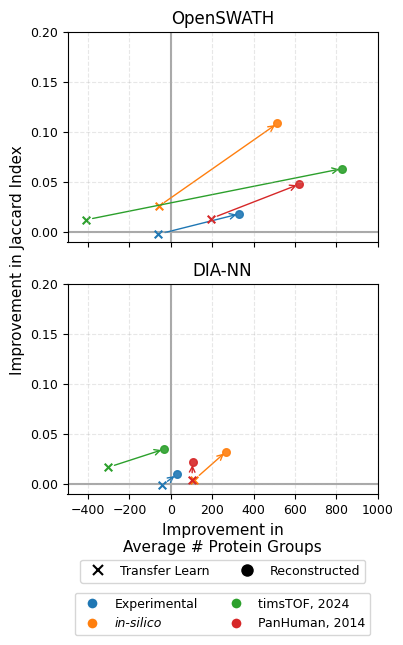

In [14]:
fig, ax = plt.subplots(2,1, figsize=(4, 6))

#createPlot_IDs_Reproduce(osw_relative, 'OpenSWATH', ax1, show_xlabel=False, show_legends=False)
createPlot_IDs_Reproduce_prot(osw_prot_relative, 'OpenSWATH', ax[0], show_xlabel=False, show_legends=False) ### DUMMY DATA for now
createPlot_IDs_Reproduce_prot(diann_prot_relative, 'DIA-NN', ax[1])

fig.text(0, 0.5, 'Improvement in Jaccard Index', va='center', ha='center', rotation='vertical', fontsize=11)

plt.savefig("Figure-S11.png", dpi=300, bbox_inches='tight')


#### **Effect Size Protein Level for Manuscript**

Already do these analysis on the precursor level in `Figure-2-Library-Reconstruction`. Here do them on the protein level. 

In [15]:
osw_prot_full['tool'] = 'OpenSWATH'
diann_prot_full['tool'] = 'DIA-NN'

In [16]:
tog_prot = pd.concat([osw_prot_full, diann_prot_full])

In [17]:
tog_prot

,Condition,Library,# IDs,Jaccard Index,tool
0,Initial,Experimental,7202.666667,0.959199,OpenSWATH
1,Reconstructed,Experimental,7534.000000,0.977602,OpenSWATH
2,Transfer-Learn,Experimental,7142.000000,0.957249,OpenSWATH
3,Initial,in-silico,7813.666667,0.845050,OpenSWATH
4,Reconstructed,in-silico,8329.333333,0.953869,OpenSWATH
5,Transfer-Learn,in-silico,7754.666667,0.870924,OpenSWATH
6,Initial,"timsTOF, 2024",7817.666667,0.915313,OpenSWATH
7,Reconstructed,"timsTOF, 2024",8645.333333,0.978865,OpenSWATH
8,Transfer-Learn,"timsTOF, 2024",7406.333333,0.927730,OpenSWATH
9,Initial,"PanHuman, 2014",6069.666667,0.928002,OpenSWATH


In [18]:
tog_prot.columns = ['condition', 'lib', 'ids', 'jaccard', 'tool']

In [19]:
# pivot so Initial and GPF are columns
wide = (
    tog_prot.pivot_table(
        index=["tool", "lib"],
        columns="condition",
        values=["ids", "jaccard"]
    )
)

# compute slope
wide["ids_vs_jaccard_slope"] = (
    (wide["ids"]["Reconstructed"] - wide["ids"]["Transfer-Learn"]) /
    (wide["jaccard"]["Reconstructed"] - wide["jaccard"]["Transfer-Learn"])
)

wide["diff_ids"] = (
    (wide["ids"]["Reconstructed"] - wide["ids"]["Transfer-Learn"])
)

wide["diff_jaccard"] = (
    (wide["jaccard"]["Reconstructed"] - wide["jaccard"]["Transfer-Learn"])
)

wide["ids_vs_jaccard_slope2"] = (
    (wide["ids"]["Reconstructed"] - wide["ids"]["Transfer-Learn"]) /
    (wide["jaccard"]["Reconstructed"] - wide["jaccard"]["Transfer-Learn"])
)

result = wide[["ids_vs_jaccard_slope", 'diff_ids', 'diff_jaccard', 'ids_vs_jaccard_slope2']].reset_index()
print(result)

                tool             lib ids_vs_jaccard_slope     diff_ids  \
condition                                                                
0             DIA-NN    Experimental          6501.902325    72.000000   
1             DIA-NN  PanHuman, 2014           172.313255     3.000000   
2             DIA-NN       in-silico          5483.174988   155.000000   
3             DIA-NN   timsTOF, 2024         14909.115939   272.000000   
4          OpenSWATH    Experimental         19260.240568   392.000000   
5          OpenSWATH  PanHuman, 2014         12447.135015   429.000000   
6          OpenSWATH       in-silico          6928.269607   574.666667   
7          OpenSWATH   timsTOF, 2024         24229.782025  1239.000000   

          diff_jaccard ids_vs_jaccard_slope2  
condition                                     
0             0.011074           6501.902325  
1             0.017410            172.313255  
2             0.028268           5483.174988  
3             0.018244  

In [20]:
result_mean = result[['tool', 'diff_ids']].groupby("tool").mean()
result_mean

/tmp/ipykernel_2136655/2032819387.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  result_mean = result[['tool', 'diff_ids']].groupby("tool").mean()


,diff_ids
condition,
tool,
DIA-NN,125.500000
OpenSWATH,658.666667


In [21]:
result_mean.loc['OpenSWATH', 'diff_ids'] / result_mean.loc['DIA-NN', 'diff_ids']

condition
    5.24834
dtype: float64

In [22]:
result_mean = result[['tool', 'diff_jaccard']].groupby("tool").mean()
result_mean

/tmp/ipykernel_2136655/1877453859.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  result_mean = result[['tool', 'diff_jaccard']].groupby("tool").mean()


,diff_jaccard
condition,
tool,
DIA-NN,0.018749
OpenSWATH,0.047225


In [23]:
result_mean.loc['OpenSWATH', 'diff_jaccard'] / result_mean.loc['DIA-NN', 'diff_jaccard']

condition
    2.51879
dtype: float64